# Regressione con PCA e Modelli Lineari

Questo notebook esplora il dataset **Linnerud**, un dataset classico di regressione multi-output che raccoglie misurazioni fisiologiche e prestazioni fisiche di 20 uomini di mezza età iscritti a una palestra.

L'obiettivo è costruire e confrontare modelli di regressione lineare (**Linear Regression**, **Lasso**, **Ridge**) in grado di predire variabili fisiologiche a partire da dati di esercizio fisico.

### Dataset

| Tipo | Variabili | Descrizione |
|------|-----------|-------------|
| **Features (X)** | `Chins`, `Situps`, `Jumps` | Numero di trazioni, addominali e salti eseguiti |
| **Target (y)** | `Weight`, `Waist`, `Pulse` | Peso corporeo (lb), girovita (in), frequenza cardiaca (bpm) |

### Pipeline di Analisi

1. **Caricamento ed esplorazione** del dataset con statistiche descrittive e visualizzazione 3D

2. **Preprocessing**: standardizzazione con `StandardScaler` e riduzione dimensionale con `PCA`

3. **Training e valutazione** dei modelli su due configurazioni di target:
   - Prima componente principale del target (`PC1`)
   - Variabile singola (`Waist`)

4. **Analisi comparativa** dei risultati (RMSE, R²)

5. **Training e valutazione** dei modelli su prima componete principale delle features del target (`PC1 Features` - `PC1 Target`) 

### Import & Configurazione

In [2]:
# IMPORT E CONFIGURAZIONE STILE

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import matplotlib as mpl
from mpl_toolkits.mplot3d import Axes3D

from sklearn.datasets import load_linnerud
from sklearn.linear_model import LinearRegression, Lasso, Ridge
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import root_mean_squared_error, r2_score

# --- Configurazione Matplotlib ---
plt.style.use('seaborn-v0_8-whitegrid')

mpl.rcParams.update({
    # Figura
    'figure.dpi': 120,
    'figure.facecolor': 'white',
    # Font
    'font.family': 'sans-serif',
    'font.size': 11,
    'axes.titlesize': 13,
    'axes.titleweight': 'bold',
    'axes.labelsize': 11,
    # Assi
    'axes.spines.top': False,
    'axes.spines.right': False,
    # Linee e marcatori
    'lines.linewidth': 2,
    'lines.markersize': 7,
    # Legenda
    'legend.frameon': True,
    'legend.framealpha': 0.9,
    'legend.fontsize': 10,
    # Ciclo colori
    'axes.prop_cycle': mpl.cycler(color=['#2196F3', '#E91E63', '#4CAF50', '#FF9800']),
})


# --- Configurazione stile tabelle ---
def highlight_best(s):
    """Evidenzia il valore migliore per ogni colonna (min RMSE, max R²)."""
    if s.name == 'RMSE':
        is_best = s == s.min()
    else:
        is_best = s == s.max()
    return ['background-color: #4CAF50; font-weight: bold' if v else '' for v in is_best]

table_style = [
        {'selector': 'caption', 'props': [
            ('font-size', '13px'), ('font-weight', 'bold'),
            ('text-align', 'left'), ('padding-bottom', '6px')]},
        {'selector': 'th',      'props': [
            ('background-color', '#1565C0'), ('color', 'white'),
            ('font-size', '12px'), ('text-align', 'center'),
            ('padding', '6px 12px')]},
        {'selector': 'td',      'props': [
            ('text-align', 'center'), ('padding', '5px 12px'),
            ('font-size', '12px')]},
    ]

## Caricamento e Descrizione Dataset

In [3]:
# CARICAMENTO DATASET LINNERUD

print('='*80)
print('DATASET LINNERUD'.center(80))
print('='*80 + '\n')

# Caricamento dati
data_linn = load_linnerud()

# Descrizione dataset
print(data_linn.DESCR)
print('-'*80 + '\n')

# --- Features ---
print('Features')
print('-'*80)
features = data_linn.data
features_names = data_linn.feature_names

print('\nDimensioni features:')
print(features.shape)
print('\nNomi features:')
for name in features_names:
    print(f'  - {name}')
print('\nCampione dati features:')
print(features[:5])
print('-'*80 + '\n')

# --- Target --- 
print('Target')
print('-'*80)
target_data = data_linn.target
target_names = data_linn.target_names

print('\nDimensioni target:')
print(target_data.shape)
print('\nNomi target:')
for name in target_names:
    print(f'  - {name}')
print('\nCampione dati target:')
print(target_data[:5])
print('='*80)

                                DATASET LINNERUD                                

.. _linnerrud_dataset:

Linnerrud dataset
-----------------

**Data Set Characteristics:**

:Number of Instances: 20
:Number of Attributes: 3
:Missing Attribute Values: None

The Linnerud dataset is a multi-output regression dataset. It consists of three
exercise (data) and three physiological (target) variables collected from
twenty middle-aged men in a fitness club:

- *physiological* - CSV containing 20 observations on 3 physiological variables:
   Weight, Waist and Pulse.
- *exercise* - CSV containing 20 observations on 3 exercise variables:
   Chins, Situps and Jumps.

.. dropdown:: References

   * Tenenhaus, M. (1998). La regression PLS: theorie et pratique. Paris:
     Editions Technic.

--------------------------------------------------------------------------------

Features
--------------------------------------------------------------------------------

Dimensioni features:
(20, 3)

Nomi featu

## Statistiche Descrittive

In [4]:
# STATISTICHE DATASET

# Conversione features e target in DataFrame
df_feat = pd.DataFrame(features, columns=features_names)
df_target = pd.DataFrame(target_data, columns=target_names)

print('='*80)
print('STATISTICHE DATASET'.center(80))
print('='*80 + '\n')

# --- Statistiche features ---
print('Features')
print('-'*80)
print(df_feat.describe().round(2).T.to_string())
X = df_feat.to_numpy()
print('-'*80 + '\n')

# --- Statistiche target ---
print('Target')
print('-'*80)
print(df_target.describe().round(2).T.to_string())
y = df_target.to_numpy()
print('='*80)

                              STATISTICHE DATASET                               

Features
--------------------------------------------------------------------------------
        count    mean    std   min     25%    50%     75%    max
Chins    20.0    9.45   5.29   1.0    4.75   11.5   13.25   17.0
Situps   20.0  145.55  62.57  50.0  101.00  122.5  210.00  251.0
Jumps    20.0   70.30  51.28  25.0   39.50   54.0   85.25  250.0
--------------------------------------------------------------------------------

Target
--------------------------------------------------------------------------------
        count   mean    std    min     25%    50%    75%    max
Weight   20.0  178.6  24.69  138.0  160.75  176.0  191.5  247.0
Waist    20.0   35.4   3.20   31.0   33.00   35.0   37.0   46.0
Pulse    20.0   56.1   7.21   46.0   51.50   55.0   60.5   74.0


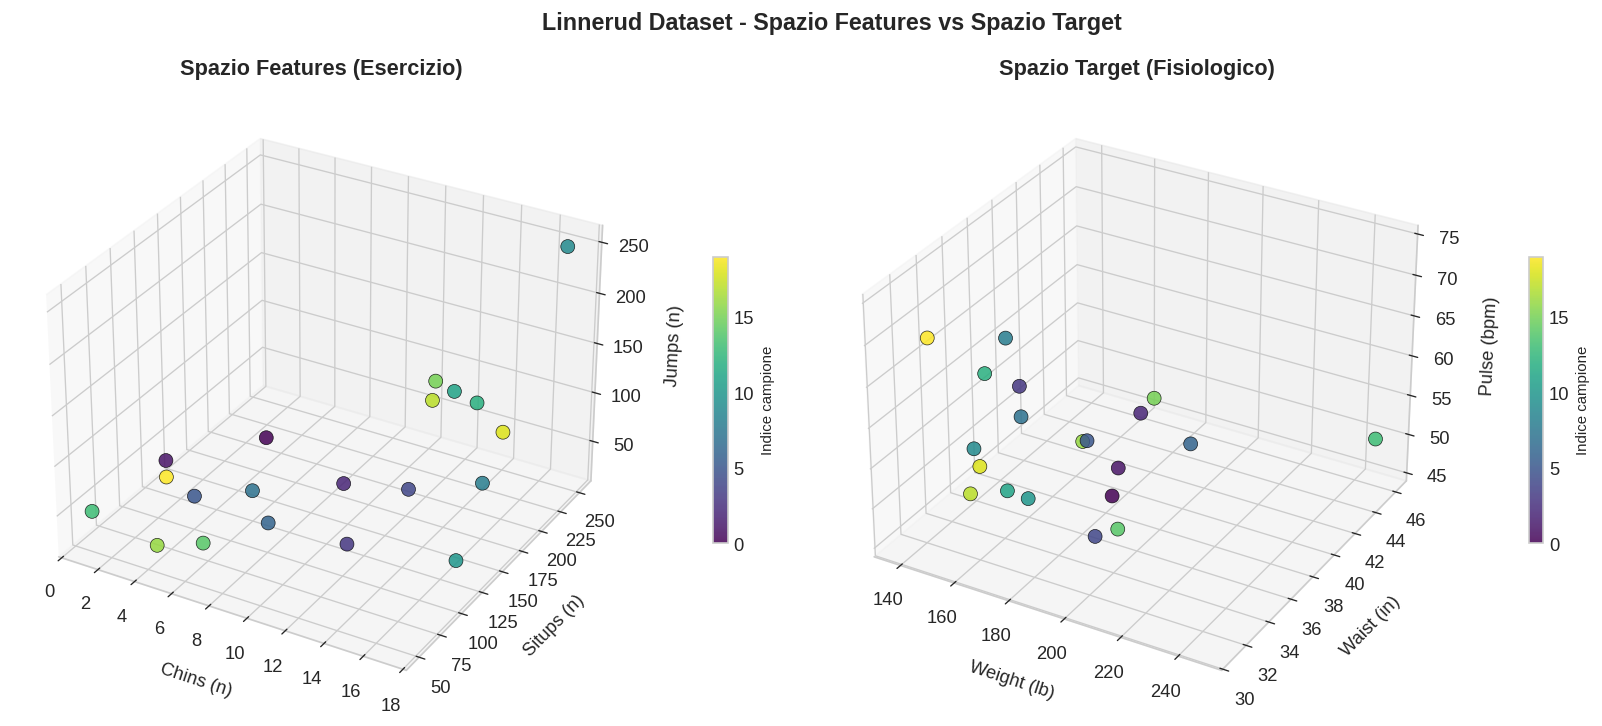

In [5]:
# VISUALIZZAZIONE DATASET

fig = plt.figure(figsize=(14, 6))
fig.suptitle('Linnerud Dataset - Spazio Features vs Spazio Target', fontsize=14, fontweight='bold', y=1.01)

colors = np.arange(len(df_feat))

# --- Spazio Features ---
ax1 = fig.add_subplot(121, projection='3d')
sc1 = ax1.scatter(
    df_feat['Chins'], df_feat['Situps'], df_feat['Jumps'],
    c=colors, cmap='viridis', s=70, edgecolors='k', linewidths=0.4, alpha=0.85
)
ax1.set_title('Spazio Features (Esercizio)', pad=10)
ax1.set_xlabel('Chins (n)', labelpad=8)
ax1.set_ylabel('Situps (n)', labelpad=8)
ax1.set_zlabel('Jumps (n)', labelpad=8)

# Aggiungi colorbar
cb1 = fig.colorbar(sc1, ax=ax1, shrink=0.45, pad=0.1)
cb1.set_label('Indice campione', fontsize=9)

# --- Spazio Target ---
ax2 = fig.add_subplot(122, projection='3d')
sc2 = ax2.scatter(
    df_target['Weight'], df_target['Waist'], df_target['Pulse'],
    c=colors, cmap='viridis', s=70, edgecolors='k', linewidths=0.4, alpha=0.85
)
ax2.set_title('Spazio Target (Fisiologico)', pad=10)
ax2.set_xlabel('Weight (lb)', labelpad=8)
ax2.set_ylabel('Waist (in)', labelpad=8)
ax2.set_zlabel('Pulse (bpm)', labelpad=8)

# Aggiungi colorbar
cb2 = fig.colorbar(sc2, ax=ax2, shrink=0.45, pad=0.1)
cb2.set_label('Indice campione', fontsize=9)

plt.tight_layout()
plt.show()

### Osservazioni

Il dataset è composto da soli **20 campioni**, una dimensione estremamente ridotta per applicazioni di machine learning. Con un numero così limitato di osservazioni, i modelli tendono ad avere varianza elevata e i risultati non sono statisticamente generalizzabili.

Dalla visualizzazione 3D non emergono pattern chiari tra lo spazio delle features e quello del target, il che suggerisce una **correlazione debole** tra le variabili di esercizio e quelle fisiologiche. Questo si rifletterà inevitabilmente nelle metriche di valutazione dei modelli.

## Preprocessing Dataset

Prima di addestrare i modelli, è necessario preparare i dati in due fasi.

**Standardizzazione** (`StandardScaler`): le tre features hanno scale molto diverse (Chins: 1–17, Situps: 50–251, Jumps: 25–250). Senza normalizzazione, i modelli con regolarizzazione come Lasso e Ridge penalizzerebbero in modo asimmetrico le variabili a scala maggiore. La stessa logica si applica al target prima di applicare la PCA.

**PCA** (Principal Component Analysis): riduce la dimensionalità proiettando i dati sugli assi di massima varianza. Applicata alle features standardizzate, permette di ottenere una rappresentazione compatta dello spazio di input. Applicata al target, consente di sintetizzare le tre variabili fisiologiche in un'unica componente che cattura la direzione di maggiore variabilità.

> **Nota**: standardizzare il target *prima* della PCA è fondamentale. Senza scaling, la PCA è dominata dalla variabile con varianza assoluta maggiore (in questo caso `Weight`, con deviazione standard ~25), ignorando le altre. Lo vedremo nel test comparativo.

In [6]:
# PREPROCESSING DATASET

print('='*80)
print('PREPROCESSING DATASET'.center(80))
print('='*80 + '\n')

#--- Features ---

# Standardizzazione
print('Standardizzazione Features')
print('-'*80)
scaler_x = StandardScaler()
X_scaled = scaler_x.fit_transform(X)

for i, name in enumerate(features_names):
    print(f'\nFeature {name.capitalize()}:\n')
    print(f'  - Media    :  {X_scaled[:,i].mean():.2e}')
    print(f'  - Dev. std :  {X_scaled[:,i].std():.2f}')
print('-'*80)

# PCA
print('\nApplicazione PCA alle Features')
print('-'*80)
pca_ft = PCA()
pca_features = pca_ft.fit_transform(X_scaled)

print('\nVarianza spiegata PC Features:\n')
for i, ratio in enumerate(pca_ft.explained_variance_ratio_): 
    print(f'  - PC{i+1}: {ratio:.2%}')
print('-'*80 +'\n')


# --- Target ---

# Standardizzazione
print('Standardizzazione Target')
print('-'*80)
scaler_y = StandardScaler()
y_scaled = scaler_y.fit_transform(y)

for i, name in enumerate(target_names):
    print(f'\nTarget {name.capitalize()}:\n')
    print(f'  - Media    :  {y_scaled[:,i].mean():.2e}')
    print(f'  - Dev. std :  {y_scaled[:,i].std():.2f}')

# PCA
print('\nApplicazione PCA al Target')
print('-'*80)
pca_tg = PCA()
pca_target = pca_tg.fit_transform(y_scaled)

print('\nVarianza spiegata PC Target:\n')
for i, ratio in enumerate(pca_tg.explained_variance_ratio_): 
    print(f'  - PC{i+1} Ratio: {ratio:.2%}')
print('-'*80)

# Target singolo manuale
single_target = df_target['Waist'].to_numpy()
print('\nTarget singolo "Waist" selezionato!')
print('='*80)

# Dizionario target
targets = {
    'PCA'   : pca_target[:, 0],  # solo PC1
    'Single': single_target
}

                             PREPROCESSING DATASET                              

Standardizzazione Features
--------------------------------------------------------------------------------

Feature Chins:

  - Media    :  1.78e-16
  - Dev. std :  1.00

Feature Situps:

  - Media    :  -2.16e-16
  - Dev. std :  1.00

Feature Jumps:

  - Media    :  3.33e-17
  - Dev. std :  1.00
--------------------------------------------------------------------------------

Applicazione PCA alle Features
--------------------------------------------------------------------------------

Varianza spiegata PC Features:

  - PC1: 74.81%
  - PC2: 16.83%
  - PC3: 8.35%
--------------------------------------------------------------------------------

Standardizzazione Target
--------------------------------------------------------------------------------

Target Weight:

  - Media    :  2.55e-16
  - Dev. std :  1.00

Target Waist:

  - Media    :  4.44e-16
  - Dev. std :  1.00

Target Pulse:

  - Media    :  

## Addestramento Modelli

Vengono addestrati tre modelli di regressione lineare su due configurazioni di target alternative:
- **`LinearRegression`**
- **`Lasso`** ($\alpha$ = 0.1)
- **`Ridge`** ($\alpha$ = 1.0)

I target considerati sono:
- **`PCA`**: prima componente principale del target standardizzato (sintesi delle 3 variabili fisiologiche)
- **`Single`**: variabile `Waist` (girovita), scelta come target diretto

In [7]:
# ADDESTRAMENTO MODELLI

print('='*80)
print('ADDESTRAMENTO MODELLI'.center(80))
print('='*80)

# --- Modelli ---
models = {
    'Lineare': LinearRegression(),
    'Lasso' : Lasso(alpha=0.1),
    'Ridge' : Ridge(alpha=1.0)
}

# --- Addestramento ---
results = []

for name_model, model in models.items():
    for name_target, target in targets.items():
        print(f'\nAddestramento modello {name_model} con target {name_target}:')
        print('-'*80)
        model.fit(X_scaled, target)
        y_pred = model.predict(X_scaled)
        rmse = root_mean_squared_error(target, y_pred)
        r2 = r2_score(target, y_pred)
        results.append({
            'Model' : name_model,
            'Target': name_target,
            'RMSE'  : rmse,
            'R²'    : r2
        })
        print(
            f'  - RMSE: {rmse:.4f}\n'
            f'  - R²  : {r2:.4f}'    
        )
        print('-'*80)

print("\nAddestramento completato!")
print("="*80)

                             ADDESTRAMENTO MODELLI                              

Addestramento modello Lineare con target PCA:
--------------------------------------------------------------------------------
  - RMSE: 1.1264
  - R²  : 0.3970
--------------------------------------------------------------------------------

Addestramento modello Lineare con target Single:
--------------------------------------------------------------------------------
  - RMSE: 2.0986
  - R²  : 0.5478
--------------------------------------------------------------------------------

Addestramento modello Lasso con target PCA:
--------------------------------------------------------------------------------
  - RMSE: 1.1543
  - R²  : 0.3668
--------------------------------------------------------------------------------

Addestramento modello Lasso con target Single:
--------------------------------------------------------------------------------
  - RMSE: 2.1136
  - R²  : 0.5413
--------------------------

In [8]:
# TABELLA RISULTATI

# Creazione DataFrame risultati
results_df = pd.DataFrame(results).set_index(['Model', 'Target'])

styled = (
    results_df
    .round(4)
    .style
    .apply(highlight_best, axis=0)
    .format({'RMSE': '{:.4f}', 'R²': '{:.4f}'})
    .set_caption('Risultati modelli: X_scaled - PC1 / Waist')
    .set_table_styles(table_style)
)

display(styled)

In [9]:
# TEST: SENZA STANDARDIZZAZIONE DEL TARGET

print('='*80)
print('TEST COMPARATIVO: SENZA STANDARDIZZAZIONE TARGET'.center(80))
print('='*80 + '\n')

print('Applicazione PCA al target non standardizzato')
pca_test = PCA()
target_test = pca_test.fit_transform(y)
print('PCA applicata al target non standardizzato!\n')
print('-'*80)
print('\nVarianza spiegata PC Target:\n')

for i, ratio in enumerate(pca_test.explained_variance_ratio_): 
    print(f'  - PC{i+1} Ratio: {ratio:.2%}')
print('-'*80)

model = models['Lineare']
model.fit(X_scaled, target_test)
y_pred = model.predict(X_scaled)
rmse = root_mean_squared_error(target_test, y_pred)
r2 = r2_score(target_test, y_pred)

print("\nRisultati:\n")
print(f'  - RMSE: {rmse:.4f}')
print(f'  - R²  : {r2:.4f}')
print('='*80)

                TEST COMPARATIVO: SENZA STANDARDIZZAZIONE TARGET                

Applicazione PCA al target non standardizzato
PCA applicata al target non standardizzato!

--------------------------------------------------------------------------------

Varianza spiegata PC Target:

  - PC1 Ratio: 93.01%
  - PC2 Ratio: 6.62%
  - PC3 Ratio: 0.36%
--------------------------------------------------------------------------------

Risultati:

  - RMSE: 9.4684
  - R²  : 0.2262


### Osservazioni

I valori di R² confermano le aspettative: con soli 20 campioni e una correlazione debole tra features e target, i modelli ottengono performance modeste. Il valore migliore si raggiunge con `Waist` come target singolo (~0.55), mentre la PC1 del target ottiene circa 0.40.

La differenza tra i tre modelli è trascurabile, segno che la regolarizzazione non apporta benefici significativi su un dataset così piccolo.

**Test senza standardizzazione del target**: applicando la PCA direttamente sul target grezzo, la PC1 cattura il **93%** della varianza (contro il 70% con scaling), ma questa varianza è quasi interamente dovuta alla scala di `Weight`. Il modello addestrato su questa componente ottiene R²=0.23, peggiore del caso con scaling corretto, dimostrando che una varianza spiegata elevata dalla PCA non implica necessariamente un target più informativo per la regressione.

## Ri-addestramento con PC1 Features - PC1 Target

Per analizzare la relazione tra le componenti principali di features e target, riaddestriamo i modelli in uno spazio ridotto 1D: utilizziamo esclusivamente la **PC1 delle features** (74.8% varianza spiegata) per predire la **PC1 del target** (70.1% della varianza spiegata).

Questo approccio consente di visualizzare le rette di regressione su un piano 2D e di confrontare direttamente come i tre modelli si comportano nella direzione di massima variabilità del dataset.

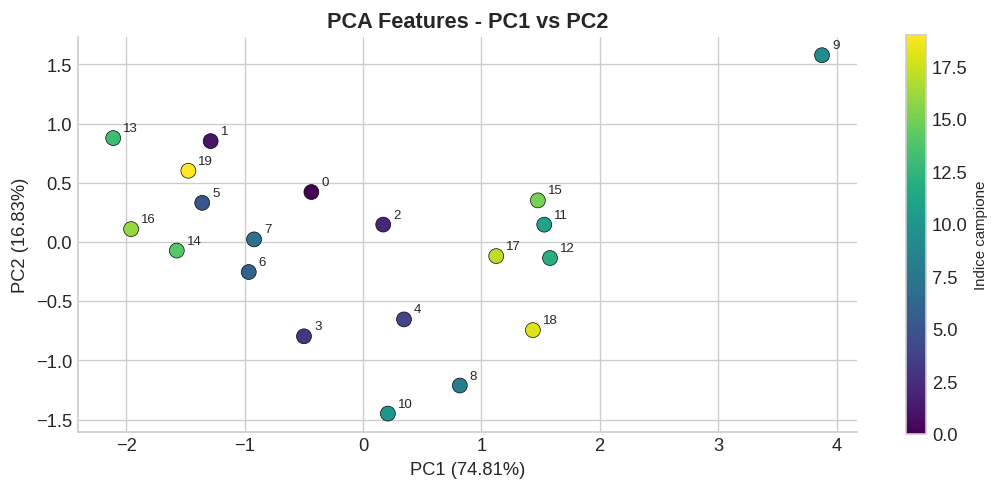

In [10]:
# VISUALIZZAZIONE FEATURES (PC1 - PC2)

# Varianza spiegata
var1, var2 = pca_ft.explained_variance_ratio_[:2]

# --- Plot ---
fig, ax = plt.subplots(figsize=(9, 4))

sc = ax.scatter(
    pca_features[:, 0], pca_features[:, 1],
    c=np.arange(len(pca_features)), cmap='viridis',
    s=80, edgecolors='k', linewidths=0.4, zorder=3
)

# Annotazione indici campioni
for i, (x, y) in enumerate(zip(pca_features[:, 0], pca_features[:, 1])):
    ax.annotate(
        str(i), (x, y), 
        textcoords='offset points', 
        xytext=(6, 4),
        fontsize=8
    )

ax.set_title('PCA Features - PC1 vs PC2')
ax.set_xlabel(f'PC1 ({var1:.2%})')
ax.set_ylabel(f'PC2 ({var2:.2%})')
ax.set_aspect('equal')
cb = fig.colorbar(sc, ax=ax)
cb.set_label('Indice campione', fontsize=9)

plt.tight_layout()
plt.show()

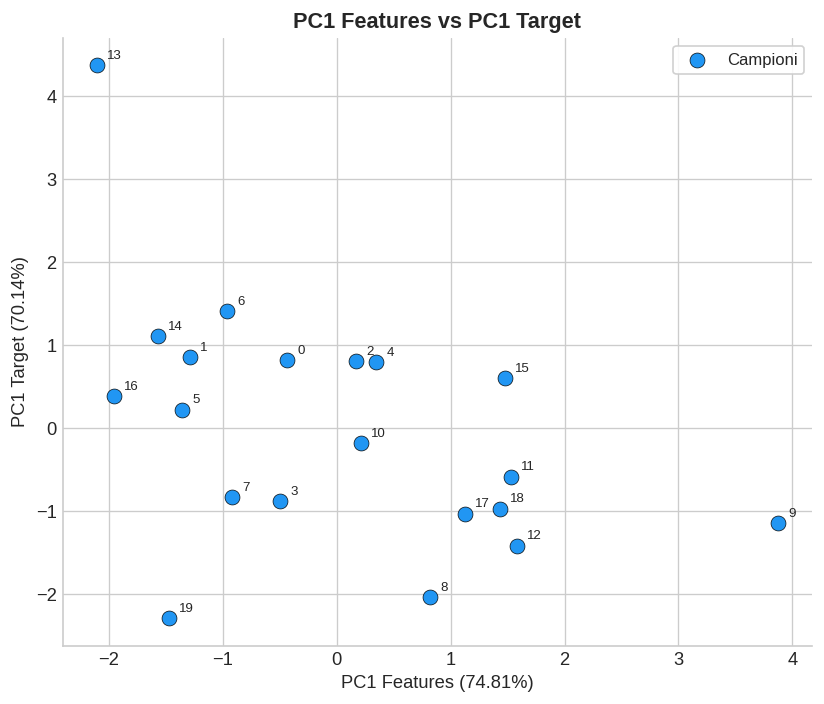

In [11]:
# VISUALIZZAZIONE DATASET (PC1 FEATURES - PC1 TARGET)

var_ft = pca_ft.explained_variance_ratio_[0]
var_tg = pca_tg.explained_variance_ratio_[0]

fig, ax = plt.subplots(figsize=(7, 6))

ax.scatter(
    pca_features[:, 0], pca_target[:, 0],
    color='#2196F3', edgecolors='k', linewidths=0.4,
    s=80, zorder=3, label='Campioni'
)

# Annotazione indici campioni
for i, (x, y) in enumerate(zip(pca_features[:, 0], pca_target[:, 0])):
    ax.annotate(
        str(i), (x, y), 
        textcoords='offset points', 
        xytext=(6, 4),
        fontsize=8
    )

ax.set_title('PC1 Features vs PC1 Target')
ax.set_xlabel(f'PC1 Features ({var_ft:.2%})')
ax.set_ylabel(f'PC1 Target ({var_tg:.2%})')
ax.legend()

plt.tight_layout()
plt.show()

In [12]:
# ADDESTRAMENTO MODELLI (PC1 FEATURES - PC1 TARGET)

print('='*80)
print('ADDESTRAMENTO MODELLI (PC1 FEATURES - PC1 TARGET)'.center(80))
print('='*80 + '\n')

X_pca = pca_features[:, 0].reshape(-1,1)
y_pca = pca_target[:, 0].reshape(-1,1)

pca_results = []

for name_model, model in models.items():
    print(f'Addestramento modello {name_model}:')
    model.fit(X_pca, y_pca)
    y_pred = model.predict(X_pca)
    rmse = root_mean_squared_error(y_pca, y_pred)
    r2 = r2_score(y_pca, y_pred)
    model_coef = model.coef_[0][0] if name_model == 'Lineare' else model.coef_[0]
    model_intercept = model.intercept_[0]
    pca_results.append({
        'Modello'  : name_model,
        'RMSE'     : rmse,
        'R²'       : r2,
        'Coef'     : model_coef,
        'Intercetta': model_intercept
    })
    print(
        f'  - RMSE: {rmse:.4f}\n'
        f'  - R²  : {r2:.4f}\n'    
    )
    print('-'*80)

print("\nAddestramento completato!")
print('='*80)

               ADDESTRAMENTO MODELLI (PC1 FEATURES - PC1 TARGET)                

Addestramento modello Lineare:
  - RMSE: 1.2741
  - R²  : 0.2285

--------------------------------------------------------------------------------
Addestramento modello Lasso:
  - RMSE: 1.2758
  - R²  : 0.2264

--------------------------------------------------------------------------------
Addestramento modello Ridge:
  - RMSE: 1.2742
  - R²  : 0.2284

--------------------------------------------------------------------------------

Addestramento completato!


In [13]:
# VISUALIZZAZIONE RISULTATI

pca_results_df = pd.DataFrame(pca_results).set_index('Modello')

styled_pca = (
    pca_results_df
    .round(4)
    .style
    .apply(highlight_best, subset=['RMSE', 'R²'], axis=0)
    .format({'RMSE': '{:.4f}', 'R²': '{:.4f}', 'Coef': '{:.4f}', 'Intercetta': '{:.2e}'})
    .set_caption('Risultati modelli: PC1 Features - PC1 Target')
    .set_table_styles(table_style)
)

display(styled_pca)

,RMSE,R²,Coef,Intercetta
Modello,,,,
Lineare,1.2741,0.2285,-0.4629,-0.00e+00
Lasso,1.2758,0.2264,-0.4183,-0.00e+00
Ridge,1.2742,0.2284,-0.4528,-0.00e+00


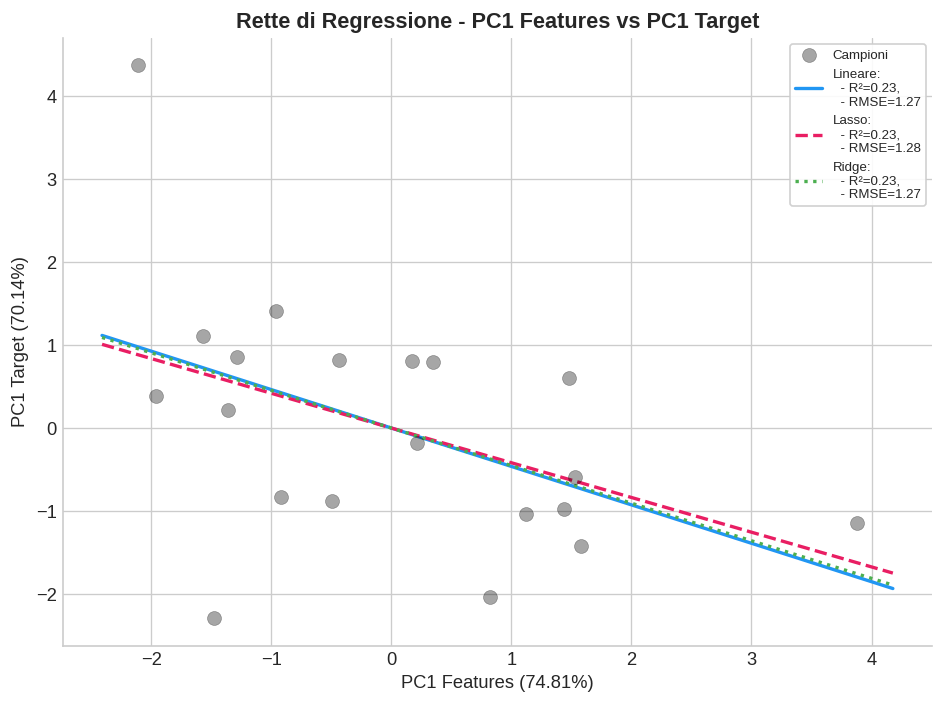

In [14]:
# VISUALIZZAZIONE RISULTATI

fig, ax = plt.subplots(figsize=(8, 6))

# Scatter dei dati
ax.scatter(
    X_pca, y_pca, color='black', edgecolors='k', linewidths=0.4,
    s=70, zorder=5, label='Campioni', alpha=0.35
)

x_line = np.linspace(X_pca.min() - 0.3, X_pca.max() + 0.3, 200)

linestyles = {'Lineare': '-', 'Lasso': '--', 'Ridge': ':'}

for model_name in pca_results_df.index:
    coef = pca_results_df.loc[model_name]['Coef']
    intercept = pca_results_df.loc[model_name]['Intercetta']
    r2 = pca_results_df.loc[model_name]['R²']
    rmse = pca_results_df.loc[model_name]['RMSE']

    y_line = coef * x_line + intercept
    label = f'{model_name}:\n  - R²={r2:.2f},\n  - RMSE={rmse:.2f}'
    ax.plot(
        x_line, y_line,
        linestyle=linestyles[model_name],
        linewidth=2, label=label
    )

ax.set_title('Rette di Regressione - PC1 Features vs PC1 Target')
ax.set_xlabel(
    f'PC1 Features ({var_ft:.2%})'
)
ax.set_ylabel(
    f'PC1 Target ({var_tg:.2%})'
)
ax.legend(loc='upper right', fontsize=8)

plt.tight_layout()
plt.show()

## Conclusioni

I risultati confermano le tendenze già osservate: R² ≈ 0.23 e RMSE ≈ 1.27 per tutti e tre i modelli, con differenze trascurabili tra loro. La retta di regressione ha **pendenza negativa**, indicando che chi esegue più esercizio fisico (alto PC1 features) tende ad avere valori fisiologici più bassi lungo la direzione di massima varianza del target - un risultato interpretabile, ma debole.

Il fatto che Lasso e Ridge producano coefficienti e performance pressoché identici a LinearRegression conferma che, con soli 20 campioni e una feature, la regolarizzazione non migliora le performance.

In conclusione, il dataset Linnerud non è sufficientemente grande né informativo per costruire modelli predittivi affidabili.